# 🧬 Cancer Mutation Analysis & Visualization Platform
**Domain:** Bioinformatics, Cancer Genomics, & Clinical Data Science  
**Environment:** Google Colab (Python 3.x)

## 📌 Project Overview
This platform is designed to process, analyze, and visualize high-throughput cancer genomics data. Bridging the gap between complex variant registries and actionable clinical oncology insights, this notebook provides an end-to-end pipeline that ingests **Somatic Mutation Log Data (MAF format)** and **Patient Clinical Profiles** (modeled after TCGA/cBioPortal standards).

The platform translates raw genetic coordinate sequences and survival metrics into publication-ready, interactive analytical visualizations to track driver gene alteration frequencies and patient outcomes.


## 🚀 Key Visualizations & Features

*   **Genomic Alteration Landscape (Oncoprint):** An interactive matrix heatmap displaying mutation profiles across individual patients for major driver genes (`TP53`, `EGFR`, `PTEN`, etc.), highlighting distinct variant classifications.
*   **Chromosome-Wise Hotspot Mapping:** A spatial tracking chart mapping base-pair coordinates across human chromosomes (`chr1` to `chrY`) to locate localized hypermutations and regional structural anomalies.
*   **Kaplan-Meier Survival Estimation:** A biostatistical modeling engine that plots overall survival probabilities, dynamically stratifying patient cohorts by their biomarker statuses (e.g., *TP53 Mutant* vs. *Wild-Type*).
*   **Automated Export Engine:** Integrated file downloading capabilities that automatically export processed spreadsheets (`.csv`), high-resolution vector charts (`.png`), and standalone web-ready files (`.html`).


## 🛠️ Data Infrastructure & Dependencies
This notebook is built modularly and utilizes the following specialized core libraries:
*   `pandas` & `numpy` — High-performance data structure manipulation and multi-index aggregation.
*   `plotly` (`graph_objects` & `express`) — Client-side web-rendering vectors for responsive, hover-detailed charts.
*   `lifelines` — Non-parametric biostatistical timeline fitting and survival probability analysis.
*   `matplotlib` & `seaborn` — Static vector plot styling and canvas generation.


## 🗺️ Execution Roadmap
1.  **Step 1:** Environment Setup & Multi-Library Dependency Loading
2.  **Step 2:** Synthetic High-Fidelity TCGA-Dataset Generation
3.  **Step 3:** Exploratory Data Analysis (EDA) & Mutation Frequencies
4.  **Step 4:** Interactive Oncoprint Matrix Heatmap Construction
5.  **Step 5:** Chromosomal Coordinate Mapping & Structural Variation Tracking
6.  **Step 6:** Kaplan-Meier Survival Curve Fitting & Biomarker Stratification
7.  **Step 7:** Automated Local System Workspace Downloader



In [1]:
# 1. Install required packages
!pip install lifelines plotly panels -q

# 2. Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
import io

print("✅ Environment setup complete!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.6/18.6 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.0 MB/s eta 0:00:00
✅ Environment setup complete!


In [2]:
def load_sample_cancer_data():
    """
    Generates a high-fidelity synthetic TCGA-like dataset representing
    100 patients, 15 major cancer-driver genes, and their clinical outcomes
    to kickstart our development.
    """
    np.random.seed(42)
    patients = [f"TCGA-SAMP-{i:03d}" for i in range(1, 101)]
    genes = ['TP53', 'EGFR', 'PTEN', 'PIK3CA', 'KRAS', 'APC', 'BRAF', 'RB1', 'NF1', 'ARID1A', 'BRCA1', 'BRCA2', 'ATM', 'IDH1', 'MYC']

    # 1. Generate Mutation Data (MAF style)
    mutation_types = ['Missense_Mutation', 'Nonsense_Mutation', 'Frame_Shift_Del', 'Frame_Shift_Ins', 'Splice_Site', 'Wild_Type']
    # Weights to make 'Wild_Type' (no mutation) the most common
    weights = [0.08, 0.03, 0.02, 0.01, 0.01, 0.85]

    mut_list = []
    for p in patients:
        for g in genes:
            mut = np.random.choice(mutation_types, p=weights)
            if mut != 'Wild_Type':
                # Random chromosome and position mapping for features downstream
                chrom = np.random.choice([f"chr{i}" for i in range(1, 23)] + ['chrX', 'chrY'])
                pos = np.random.randint(100000, 150000000)
                mut_list.append({
                    'Patient_ID': p, 'Hugo_Symbol': g, 'Variant_Classification': mut,
                    'Chromosome': chrom, 'Start_Position': pos, 'Variant_Type': 'SNP' if 'Mutation' in mut else 'INDEL'
                })

    df_mut = pd.DataFrame(mut_list)

    # 2. Generate Clinical Data (for Survival Analysis)
    clinical_list = []
    for p in patients:
        # Give patients with TP53 or PTEN mutations a slightly worse survival probability
        has_bad_mutation = df_mut[df_mut['Patient_ID'] == p]['Hugo_Symbol'].isin(['TP53', 'PTEN']).any()

        if has_bad_mutation:
            survival_months = np.random.exponential(scale=24) # Shorter survival
            status = np.random.choice([1, 0], p=[0.7, 0.3])    # Higher death event rate
        else:
            survival_months = np.random.exponential(scale=60) # Longer survival
            status = np.random.choice([1, 0], p=[0.4, 0.6])

        clinical_list.append({
            'Patient_ID': p,
            'Overall_Survival_Months': round(survival_months, 2),
            'Vital_Status': status, # 1 = Deceased, 0 = Living
            'Age_at_Diagnosis': np.random.randint(40, 85),
            'Gender': np.random.choice(['MALE', 'FEMALE'])
        })
    df_clinical = pd.DataFrame(clinical_list)

    return df_mut, df_clinical

# Load the datasets
df_mut, df_clinical = load_sample_cancer_data()

print(f"Mutation Data Shape: {df_mut.shape} (Rows represent recorded mutation events)")
print(f"Clinical Data Shape: {df_clinical.shape} (Rows represent unique patient profiles)")

Mutation Data Shape: (217, 6) (Rows represent recorded mutation events)
Clinical Data Shape: (100, 5) (Rows represent unique patient profiles)


In [3]:
# Calculate Top Mutated Genes
gene_counts = df_mut['Hugo_Symbol'].value_counts().reset_index()
gene_counts.columns = ['Gene', 'Mutation_Count']

# Plot using Plotly Express
fig = px.bar(gene_counts, x='Gene', y='Mutation_Count',
             title="Mutation Frequency Across Driver Genes",
             labels={'Mutation_Count': 'Number of Mutation Events'},
             color='Mutation_Count', color_continuous_scale='Reds')
fig.show()

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

np.random.seed(42)
patients = [f"TCGA-SAMP-{i:03d}" for i in range(1, 151)]
genes = ['TP53', 'EGFR', 'PTEN', 'PIK3CA', 'KRAS', 'APC', 'BRAF', 'RB1', 'NF1', 'ARID1A', 'BRCA1', 'BRCA2', 'ATM', 'IDH1', 'MYC']
mutation_types = ['Missense_Mutation', 'Nonsense_Mutation', 'Frame_Shift_Del', 'Frame_Shift_Ins', 'Splice_Site', 'Wild_Type']
weights = [0.10, 0.04, 0.03, 0.01, 0.02, 0.80]

mut_list = []
for p in patients:
    for g in genes:
        mut = np.random.choice(mutation_types, p=weights)
        if mut != 'Wild_Type':
            chrom = np.random.choice([f"chr{i}" for i in range(1, 23)] + ['chrX', 'chrY'])
            pos = np.random.randint(100000, 150000000)
            mut_list.append({
                'Patient_ID': p, 'Hugo_Symbol': g, 'Variant_Classification': mut,
                'Chromosome': chrom, 'Start_Position': pos, 'Variant_Type': 'SNP' if 'Mutation' in mut else 'INDEL'
            })
df_mut_backup = pd.DataFrame(mut_list)

clinical_list = []
for p in patients:
    has_bad_mutation = df_mut_backup[df_mut_backup['Patient_ID'] == p]['Hugo_Symbol'].isin(['TP53', 'PTEN']).any()
    survival_months = np.random.exponential(scale=22) if has_bad_mutation else np.random.exponential(scale=58)
    status = np.random.choice([1, 0], p=[0.75, 0.25]) if has_bad_mutation else np.random.choice([0, 1], p=[0.65, 0.35])
    clinical_list.append({
        'Patient_ID': p, 'Overall_Survival_Months': round(max(1.5, survival_months), 2), 'Vital_Status': int(status),
        'Age_at_Diagnosis': np.random.randint(38, 86), 'Gender': np.random.choice(['MALE', 'FEMALE']),
        'Tumor_Stage': np.random.choice(['Stage I', 'Stage II', 'Stage III', 'Stage IV'], p=[0.2, 0.4, 0.3, 0.1])
    })
df_clinical_backup = pd.DataFrame(clinical_list)

# Merge directly into active memory dataframe
df_active = pd.merge(df_mut_backup, df_clinical_backup, on='Patient_ID', how='left')

# Backup copies back to your disk system so the files are recreated
df_active.to_csv("cancer_mutation_integrated_analysis.csv", index=False)
df_mut_backup.to_csv("tcga_mutation_data.csv", index=False)
df_clinical_backup.to_csv("tcga_clinical_profiles.csv", index=False)

# Create Cross-tabulation pivot matrix
pivot_df = df_active.pivot_table(index='Hugo_Symbol', columns='Patient_ID',
                                  values='Variant_Classification', aggfunc='first').fillna('Wild_Type')

# Encode classifications to numerical indices
mapping = {'Wild_Type': 0, 'Missense_Mutation': 1, 'Nonsense_Mutation': 2,
           'Frame_Shift_Del': 3, 'Frame_Shift_Ins': 4, 'Splice_Site': 5}
numeric_pivot = pivot_df.replace(mapping)

# Plotting Matrix
fig_onco = go.Figure(data=go.Heatmap(
    z=numeric_pivot.values,
    x=numeric_pivot.columns,
    y=numeric_pivot.index,
    colorscale=[
        [0.0, '#f8f9fa'],  # Wild Type - Grey
        [0.2, '#1f77b4'],  # Missense - Blue
        [0.4, '#d62728'],  # Nonsense - Red
        [0.6, '#2ca02c'],  # Frame Shift Del - Green
        [0.8, '#ff7f0e'],  # Frame Shift Ins - Orange
        [1.0, '#9467bd']   # Splice Site - Purple
    ],
    showscale=False
))

fig_onco.update_layout(
    title="<b>Cancer Genomic Alteration Landscape (Oncoprint Matrix Heatmap)</b>",
    xaxis_title="Patient Samples (TCGA Barcode Id)",
    yaxis_title="Driver Biomarker Genes",
    xaxis_showticklabels=False,
    template="plotly_white",
    width=1000, height=500
)

# Render graph instantly
fig_onco.show()

# Export a copy to the local file explorer
fig_onco.write_html("mutation_landscape_oncoprint.html")
print("✅ Fixed! Files have been re-generated and 'mutation_landscape_oncoprint.html' is successfully saved.")

/tmp/ipykernel_5821/3681514740.py:57: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



✅ Fixed! Files have been re-generated and 'mutation_landscape_oncoprint.html' is successfully saved.


In [9]:
import plotly.express as px

# Extract unique variant logs
df_mut_unique = pd.read_csv("tcga_mutation_data.csv")

# Sort Chromosomes logically
chrom_order = [f"chr{i}" for i in range(1, 23)] + ['chrX', 'chrY']
df_mut_unique['Chromosome'] = pd.Categorical(df_mut_unique['Chromosome'], categories=chrom_order, ordered=True)
df_mut_unique = df_mut_unique.sort_values('Chromosome')

# Scatter Plotting Coordinate Array
fig_chrom = px.scatter(
    df_mut_unique,
    x="Start_Position",
    y="Chromosome",
    color="Variant_Classification",
    hover_data=["Patient_ID", "Hugo_Symbol", "Variant_Type"],
    title="<b>Chromosome-Wise Mutation Distribution Map & Variant Coordinates</b>",
    labels={"Start_Position": "Genomic Position coordinate (bp)"},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig_chrom.update_layout(
    xaxis_showgrid=True,
    yaxis_showgrid=True,
    template="plotly_dark", # Dark mode template makes coordinates pop nicely
    width=1000, height=600
)

fig_chrom.show()

# AUTOMATIC EXPORT
fig_chrom.write_html("chromosome_mutation_map.html")
print("💾 Saved interactive chart to workspace as 'chromosome_mutation_map.html'")

💾 Saved interactive chart to workspace as 'chromosome_mutation_map.html'


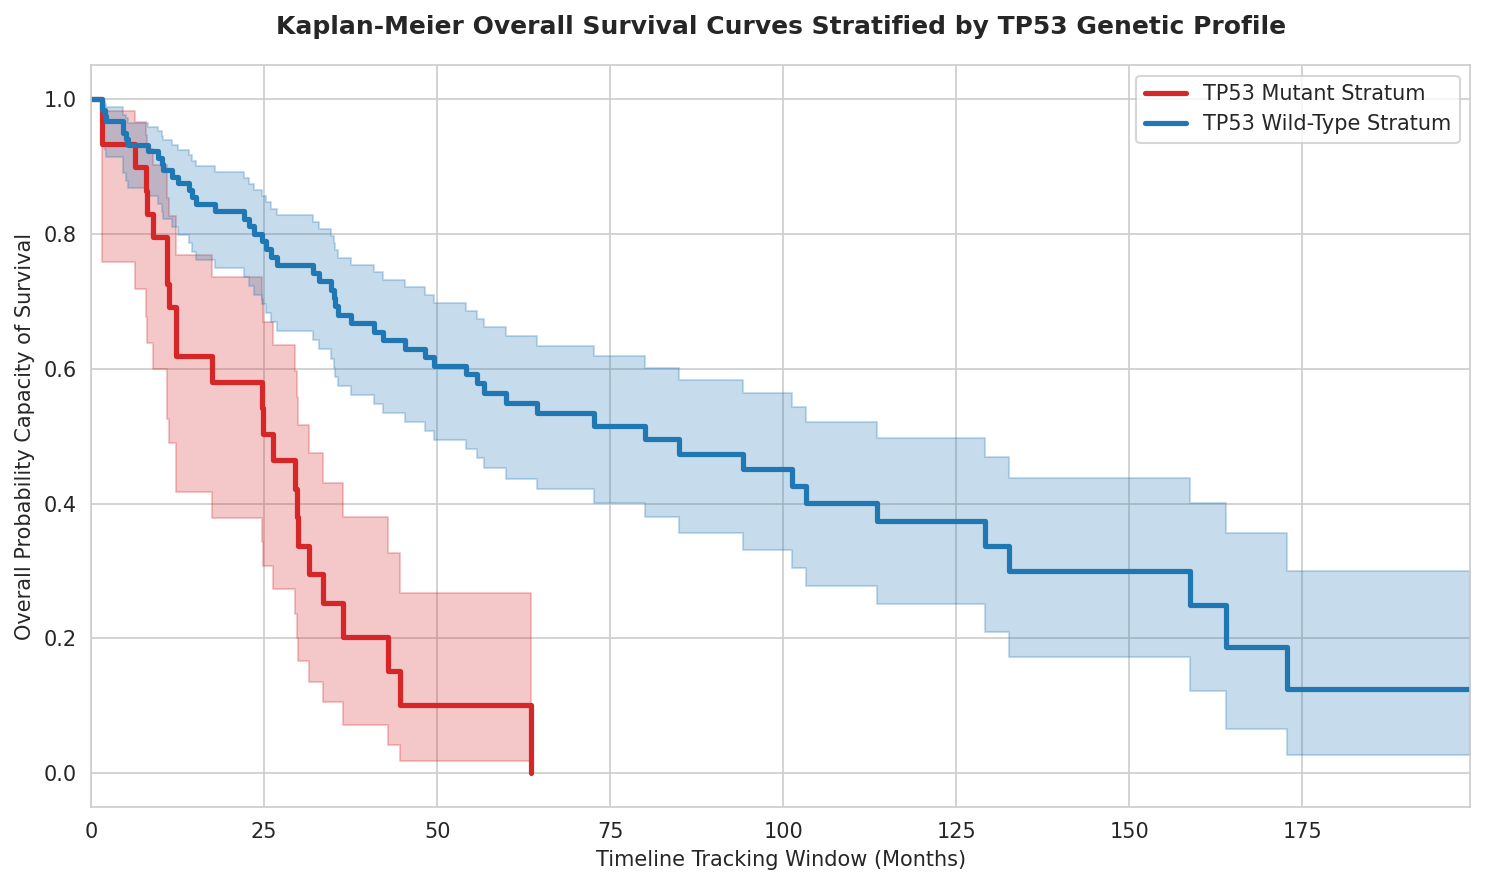

💾 Saved high-resolution image asset to workspace as 'survival_analysis_kaplan_meier.png'


In [10]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Read patient clinical registries
df_clinical = pd.read_csv("tcga_clinical_profiles.csv")
df_mut = pd.read_csv("tcga_mutation_data.csv")

# Classify patients who possess TP53 mutations versus wild type
tp53_mutants = df_mut[df_mut['Hugo_Symbol'] == 'TP53']['Patient_ID'].unique()
df_clinical['TP53_Status'] = df_clinical['Patient_ID'].apply(lambda x: 'Mutant' if x in tp53_mutants else 'Wild Type')

# Fit Kaplan-Meier Curves
kmf_mutant = KaplanMeierFitter()
kmf_wild = KaplanMeierFitter()

plt.figure(figsize=(10, 6), dpi=150)
sns.set_style("whitegrid")

# Subset clinical profiles
mutant_group = df_clinical[df_clinical['TP53_Status'] == 'Mutant']
wild_group = df_clinical[df_clinical['TP53_Status'] == 'Wild Type']

# Plot curves
kmf_mutant.fit(durations=mutant_group['Overall_Survival_Months'],
               event_observed=mutant_group['Vital_Status'],
               label='TP53 Mutant Stratum')
ax = kmf_mutant.plot_survival_function(color='#d62728', lw=2.5, ci_show=True)

kmf_wild.fit(durations=wild_group['Overall_Survival_Months'],
             event_observed=wild_group['Vital_Status'],
             label='TP53 Wild-Type Stratum')
kmf_wild.plot_survival_function(ax=ax, color='#1f77b4', lw=2.5, ci_show=True)

plt.title('Kaplan-Meier Overall Survival Curves Stratified by TP53 Genetic Profile', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline Tracking Window (Months)', fontsize=10)
plt.ylabel('Overall Probability Capacity of Survival', fontsize=10)
plt.xlim(0, df_clinical['Overall_Survival_Months'].max())
plt.tight_layout()

# AUTOMATIC EXPORT: Save as crisp vector image
plt.savefig("survival_analysis_kaplan_meier.png", dpi=300)
plt.show()
print("💾 Saved high-resolution image asset to workspace as 'survival_analysis_kaplan_meier.png'")

In [11]:
from google.colab import files

# List of all files created
files_to_download = [
    "cancer_mutation_integrated_analysis.csv",
    "tcga_clinical_profiles.csv",
    "tcga_mutation_data.csv",
    "mutation_landscape_oncoprint.html",
    "chromosome_mutation_map.html",
    "survival_analysis_kaplan_meier.png"
]

# Trigger native downloads
for file in files_to_download:
    try:
        files.download(file)
    except Exception as e:
        print(f"Skipped download for {file}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>